In [ ]:
# Resstock to Urbanopt building characterisitics disaggregation 
# Prediciting building characterisitcs using ResStock data 

"""
Created on May 04 12:00:00 2024

@authors: Rawad El Kontar

reference: https://docs.nrel.gov/docs/fy24osti/90883.pdf 

citation: 
El Kontar, Rawad, et al. 
An Open-Source Framework for Characterizing Urban Energy Models: 
Integrating Top-Down and Bottom-Up Methods to Predict Residential Buildings Characteristics.
No. NREL/CP-5500-90883. National Renewable Energy Laboratory (NREL), Golden, CO (United States), 2024.

"""

In [ ]:
pip install scikit-learn

In [1]:
import os
import json
import random
import numpy as np
from datetime import datetime
import time
from collections import defaultdict
import pandas as pd
import gzip
import csv
import matplotlib.pyplot as plt
import pickle
from sklearn.preprocessing import normalize
from collections import defaultdict
import math
import pandas as pd
from pathlib import Path

current_path = Path(os.getcwd())
data_path = current_path / '..'/ 'data' 
buildstock_metadata_path = data_path / 'NY_baseline_metadata_and_annual_results.xlsx'

# Read the "select_counties" sheet
df = pd.read_excel(buildstock_metadata_path, sheet_name="select_counties")

# Number of rows in the DataFrame
num_rows = len(df)
print("Number of rows:", num_rows)


print('done')

Number of rows: 607
done


In [2]:
# Extract input and output variables
#input_columns = [col for col in df.columns if col.startswith('in.')]
output_variable = 'out.site_energy.total.energy_consumption.kwh'
input_columns = [
    
'bldg_id', #
  
'in.sqft',
    
 'in.area_median_income',#
    
 'in.battery',
 'in.bedrooms',
 'in.ceiling_fan',
 'in.clothes_dryer',
 'in.clothes_dryer_usage_level',
 'in.clothes_washer',
 'in.clothes_washer_presence',
 'in.clothes_washer_usage_level',
 'in.cooking_range',
 'in.cooking_range_usage_level',
 'in.cooling_setpoint',
 'in.cooling_setpoint_has_offset',
 'in.cooling_setpoint_offset_magnitude',
 'in.cooling_setpoint_offset_period',
 'in.corridor',
 'in.dishwasher',
 'in.dishwasher_usage_level',
 'in.door_area',
 'in.duct_leakage_and_insulation',
 'in.duct_location',

 'in.federal_poverty_level',#
                 
 'in.geometry_attic_type',
    
 'in.geometry_building_horizontal_location_mf',#
 'in.geometry_building_horizontal_location_sfa',#
 'in.geometry_building_level_mf',#
 'in.geometry_building_number_units_mf',#
 'in.geometry_building_number_units_sfa',#


 'in.geometry_building_type_recs',
 'in.geometry_floor_area', #
 'in.geometry_floor_area_bin',
 'in.geometry_foundation_type',
 'in.geometry_garage',
 'in.geometry_stories',
 'in.geometry_stories_low_rise',
 'in.geometry_story_bin',
 'in.geometry_wall_exterior_finish',
 'in.geometry_wall_type',
    
 'in.has_pv',
 'in.heating_fuel',
 'in.heating_setpoint',
 'in.heating_setpoint_has_offset',
 'in.heating_setpoint_offset_magnitude',
 'in.heating_setpoint_offset_period',
 'in.holiday_lighting',
 'in.hot_water_distribution',
 'in.hot_water_fixtures',
                 
 'in.household_has_tribal_persons',#
                 
 'in.hvac_cooling_efficiency',
 'in.hvac_cooling_partial_space_conditioning',
 'in.hvac_cooling_type',
 'in.hvac_has_ducts',
 'in.hvac_has_shared_system',
 'in.hvac_has_zonal_electric_heating',
 'in.hvac_heating_efficiency',
 'in.hvac_heating_type',
 'in.hvac_heating_type_and_fuel',

 'in.hvac_shared_efficiencies',#
    
 'in.income_recs_2020',
    
 'in.infiltration',
 'in.insulation_ceiling',
 'in.insulation_floor',
 'in.insulation_foundation_wall',
 'in.insulation_rim_joist',
 'in.insulation_roof',
 'in.insulation_slab',
 'in.insulation_wall',
 'in.interior_shading',

 'in.lighting',
 'in.lighting_interior_use',
 'in.lighting_other_use',

 'in.mechanical_ventilation',
 'in.misc_extra_refrigerator',
 'in.misc_freezer',
 'in.misc_gas_fireplace',
 'in.misc_gas_grill',
 'in.misc_gas_lighting',
 'in.misc_hot_tub_spa',
 'in.misc_pool',
 'in.misc_pool_heater',#
 'in.misc_pool_pump',#
 'in.misc_well_pump',#
 'in.natural_ventilation',
 'in.neighbors',
 'in.occupants',
 'in.orientation',
 'in.overhangs',
 'in.plug_load_diversity',
 'in.plug_loads',

 'in.pv_orientation',
 'in.pv_system_size',
 'in.radiant_barrier',

 'in.refrigerator',
 'in.refrigerator_usage_level',
 'in.roof_material',

 'in.solar_hot_water',

 'in.tenure',

 'in.usage_level',

 'in.vacancy_status',
 'in.vintage', #
 'in.vintage_acs',
 'in.water_heater_efficiency',
 'in.water_heater_fuel',
 'in.water_heater_in_unit',

 'in.window_areas',
 'in.windows',
 'in.representative_income'#
                ]

# Create the new DataFrame with input and output variables
new_df = df[input_columns + [output_variable]]

In [3]:
new_df.head()
new_df.to_csv('cleandata_for_importance_sampling.csv', index = False)

## SENSITIVITY ANALYSIS USING RANDOM FOREST 

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# === Step 1: Prepare Data ===

def convert_to_string(X):
    return X.astype(str)

data = new_df.copy()
data = data.drop(columns=['in.sqft'])

# === Filter unwanted window categories BEFORE split ===

# Normalize the 'in.windows' column
data['in.windows'] = data['in.windows'].astype(str).str.strip().str.lower()

# List of categories to drop (in lowercase)
bad_cats = [
    'double, clear, non-metal, air, exterior clear storm',
    'single, clear, metal, exterior clear storm',
    'single, clear, non-metal, exterior clear storm',
    'triple, low-e, non-metal, air, l-gain'
]

# Drop rows with those window types
data = data[~data['in.windows'].isin(bad_cats)]

# Sanity check
print("✅ Remaining in.windows categories:")
print(data['in.windows'].unique())

# === Split X and y ===
X = data.drop(columns=['out.site_energy.total.energy_consumption.kwh'])
y = data['out.site_energy.total.energy_consumption.kwh'].astype(float)

# Drop numeric columns that are all-NaN
na_cols = X.select_dtypes(include=['float64', 'int64']).columns[X.select_dtypes(include=['float64', 'int64']).isna().all()].tolist()
print("🔍 Dropping all-NaN numerical columns:", na_cols)
X = X.drop(columns=na_cols)

# Recalculate column types
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X.select_dtypes(include=['float64', 'int64']).columns.tolist()


✅ Remaining in.windows categories:
['double, clear, non-metal, air' 'double, low-e, non-metal, air, m-gain'
 'single, clear, metal' 'single, clear, non-metal'
 'double, clear, metal, air'
 'double, clear, metal, air, exterior clear storm']
🔍 Dropping all-NaN numerical columns: ['in.battery', 'in.mechanical_ventilation', 'in.overhangs', 'in.solar_hot_water']


In [5]:

# === Step 2: Define Preprocessing ===

numerical_transformer = SimpleImputer(strategy='median')

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('to_string', FunctionTransformer(convert_to_string, validate=False)),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])


In [6]:

# === Step 3: Build Model Pipeline ===

model = RandomForestRegressor(n_estimators=100, random_state=0)

clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])


In [7]:

# === Step 4: Train/Test Split ===
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=0)

# === Step 5: Fit Model ===
clf.fit(X_train, y_train)

# === Step 6: Extract Feature Names and Importances ===
ohe = clf.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
categorical_feature_names = ohe.get_feature_names_out(input_features=categorical_cols)
feature_names = np.r_[numerical_cols, categorical_feature_names]

importances = clf.named_steps['model'].feature_importances_

print(f"length of importances: {len(importances)}")
print(f"length of feature names: {len(feature_names)}")

assert len(importances) == len(feature_names), "❌ Feature count mismatch!"


length of importances: 493
length of feature names: 493


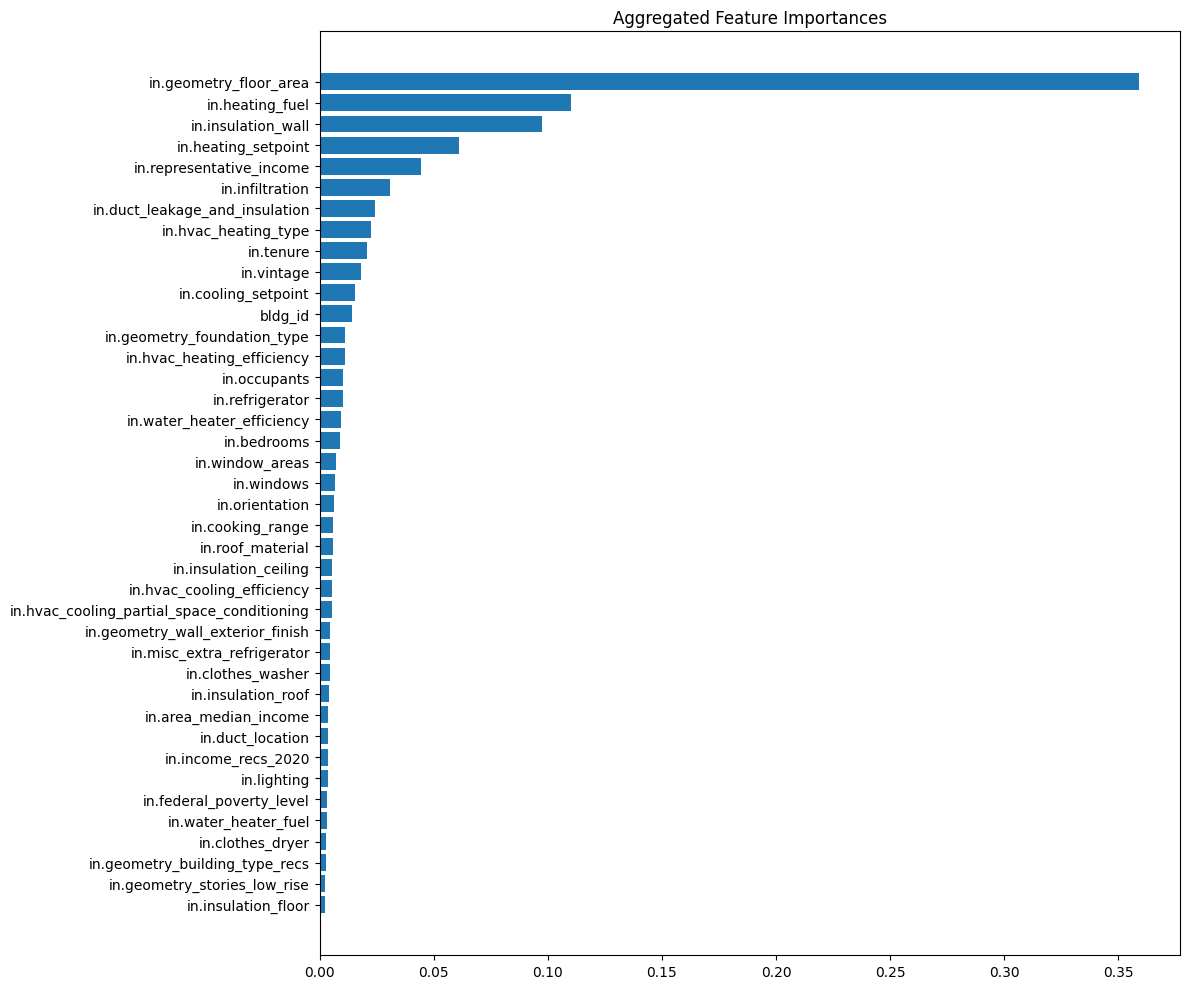

✅ Exported feature importances to aggregated_feature_importances.csv


In [8]:

# === Step 7: Aggregate Importances by Original Feature ===
original_feature_importances = dict(zip(numerical_cols, importances[:len(numerical_cols)]))

for i, feature in enumerate(feature_names[len(numerical_cols):]):
    for col in categorical_cols:
        if feature.startswith(f"{col}_"):
            original_name = col
            break
    else:
        original_name = "unknown"
    original_feature_importances[original_name] = original_feature_importances.get(original_name, 0) + importances[i + len(numerical_cols)]

sorted_features = sorted(original_feature_importances.items(), key=lambda x: x[1], reverse=True)

# === Step 8: Plot ===
plt.figure(figsize=(12, 10))
plt.title("Aggregated Feature Importances")
N = 40
top_features = sorted_features[:N]
plt.barh(range(N), [val for _, val in top_features])
plt.yticks(range(N), [key for key, _ in top_features])
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# === Step 9: Export to CSV ===
feature_df = pd.DataFrame(sorted_features, columns=["Feature", "Importance"])
feature_df.to_csv("aggregated_feature_importances.csv", index=False)
print("✅ Exported feature importances to aggregated_feature_importances.csv")


In [ ]:
# # CHECK!!!!

# # Convert to lists
# feature_names_list = list(feature_names)
# importances_list = list(importances)

# # Debug: Print lengths
# print("🔍 feature_names length:", len(feature_names_list))
# print("🔍 importances length:", len(importances_list))

# # Export separately
# pd.Series(feature_names_list, name="Feature_Name").to_csv("feature_names_list.csv", index=False)
# pd.Series(importances_list, name="Importance").to_csv("importances_list.csv", index=False)

# print("✅ Exported feature_names_list.csv and importances_list.csv")


# # Save mismatched tails, if any
# if len(feature_names_list) > len(importances_list):
#     pd.Series(feature_names_list[len(importances_list):], name="Extra_Feature_Names")\
#       .to_csv("extra_feature_names.csv", index=False)
#     print("⚠️ Extra feature names saved to extra_feature_names.csv")

# elif len(importances_list) > len(feature_names_list):
#     pd.Series(importances_list[len(feature_names_list):], name="Extra_Importances")\
#       .to_csv("extra_importances.csv", index=False)
#     print("⚠️ Extra importances saved to extra_importances.csv")
# print('done')

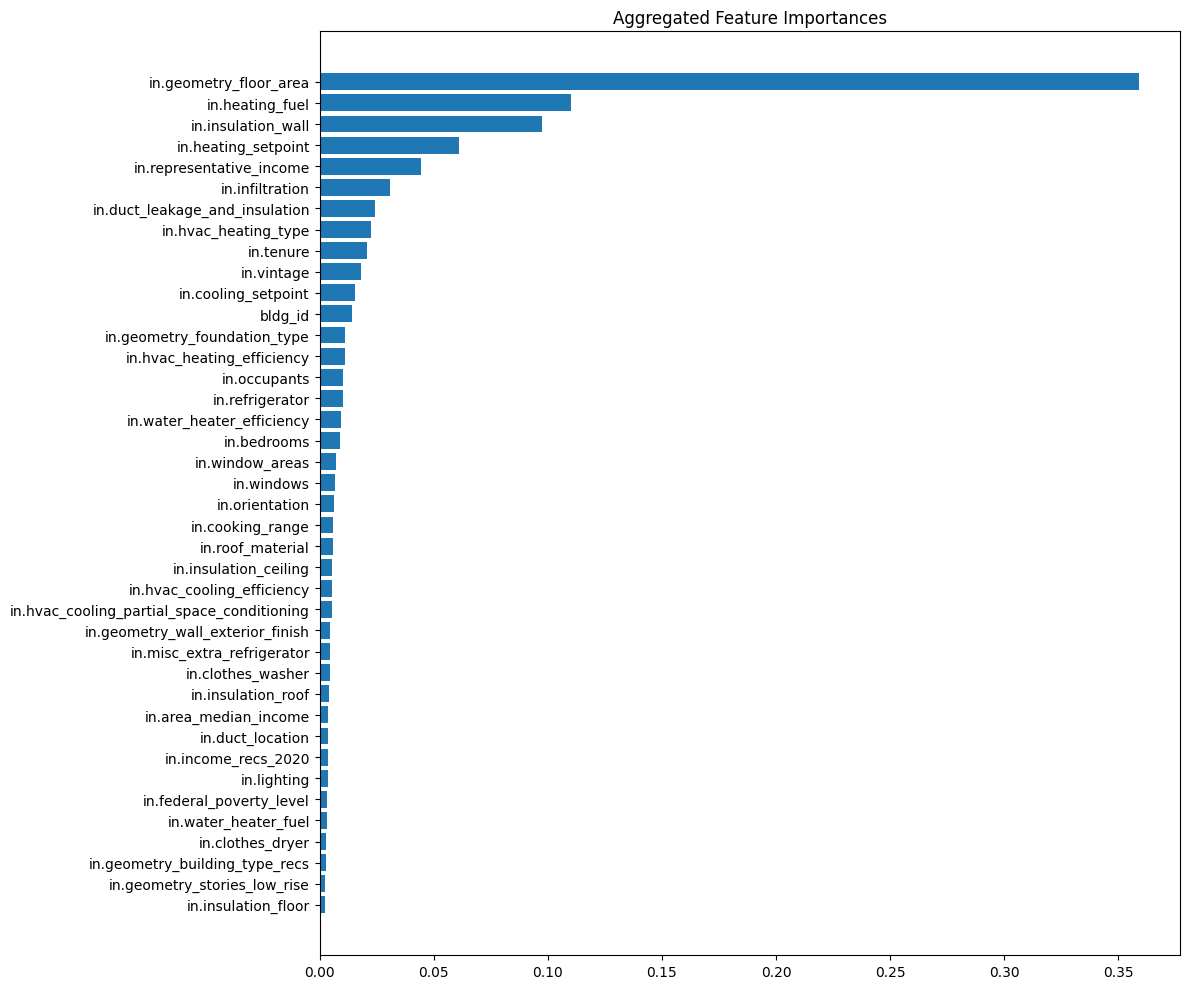

In [9]:
## SAVE 
plt.figure(figsize=(12, 10))
plt.title("Aggregated Feature Importances")

N = 40

top_features = sorted_features[:N]
bars = plt.barh(range(N), [val for _, val in top_features])

plt.yticks(range(N), [key for key, _ in top_features], rotation=0)
plt.gca().invert_yaxis() 
plt.tight_layout()  
plt.savefig('feature_importances_plot.png')
plt.show()


sorted_features_df = pd.DataFrame(sorted_features, columns=['Feature', 'Importance'])
sorted_features_df.to_csv('sorted_feature_importances.csv', index=False)


# DEVELOPING A MODEL TO PREDICT

In [27]:
import pandas as pd

sorted_features_df = pd.read_csv('sorted_feature_importances.csv')

data_all_inputs = new_df

top_20_features = sorted_features_df['Feature'].head(20).tolist()

top_20_features.append('out.site_energy.total.energy_consumption.kwh')
# BUILDING ID IS ALREADY IN TOP 20 FEATURES
#top_20_features.insert(0,'bldg_id')
# ADD ALL THE FEATURES NOT IN TOP 20, THAT ARE NEEDED TO FILTER DOWN BUILDINGS
top_20_features.extend(['in.geometry_building_type_recs','in.geometry_stories',\
                       'in.geometry_building_number_units_mf',\
                      'in.vintage_acs', 'in.hvac_cooling_type',\
                      'in.geometry_wall_type','in.roof_material',\
                    'in.geometry_garage','in.geometry_attic_type']) # add it for testing


selected_data = data_all_inputs[top_20_features]

print(selected_data.head())

# save the csv
selected_data.to_csv('selected_data.csv')

  in.geometry_floor_area in.heating_fuel      in.insulation_wall  \
0              2000-2499     Natural Gas  Wood Stud, Uninsulated   
1              1000-1499      Other Fuel  Wood Stud, Uninsulated   
2              3000-3999     Natural Gas  Wood Stud, Uninsulated   
3              3000-3999     Natural Gas  Wood Stud, Uninsulated   
4              1500-1999        Fuel Oil         Wood Stud, R-11   

  in.heating_setpoint  in.representative_income in.infiltration  \
0                 68F                     47457        30 ACH50   
1                 65F                    149501        20 ACH50   
2                 72F                    109096        20 ACH50   
3                 72F                    280058        15 ACH50   
4                 55F                         0        15 ACH50   

        in.duct_leakage_and_insulation in.hvac_heating_type      in.tenure  \
0  10% Leakage to Outside, Uninsulated       Ducted Heating          Owner   
1                               

In [41]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neighbors import NearestNeighbors

df = selected_data

# Identify categorical variables
categorical_vars = df.select_dtypes(include=['object']).columns.tolist()

# Identify numeric variables
numeric_vars = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# New buildings data known variables 
#BUILDING 1
##             "properties": {
#                "@id": "way/825066926",
#                "addr:city": "Dryden",
#                "addr:housenumber": "33",
#                "addr:postcode": "13053",
#                "addr:street": "West Main Street",
#                "building": "yes",
#                "source": "NYS GIS OpenData and ESRI sat imagery",
#                "Matched_SNo": "131",

new_building = pd.DataFrame({'in.geometry_building_type_recs': ['Single-Family Detached'], 
                   'in.geometry_floor_area': ['1000-1499'], 
                   'in.heating_fuel': ['Natural Gas'],
                    'in.bedrooms':[4],
                    'in.geometry_stories': [2],
                    'in.vintage_acs':['1940-59'],
                    #'out.site_energy.total.energy_consumption.kwh':[30000]
                             }, index=[0])


# Define the number of matches you want to find
n_matches = 25

relevant_columns = new_building.columns.tolist()
df_relevant = df[relevant_columns + ['bldg_id']]  # Include 'bldg_id' for identification


df_relevant_fixed = df_relevant.fillna('missing')
df_relevant_fixed[relevant_columns] = df_relevant_fixed[relevant_columns].astype(str)

new_building_fixed = new_building.fillna('missing')
new_building_fixed[relevant_columns] = new_building_fixed[relevant_columns].astype(str)

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('cat', categorical_transformer, relevant_columns)
])

df_relevant_transformed_fixed = preprocessor.fit_transform(df_relevant_fixed.drop(columns=['bldg_id']))
new_building_transformed_fixed = preprocessor.transform(new_building_fixed)

# NearestNeighbors to find the closest matches
neighbors = NearestNeighbors(n_neighbors=n_matches)
neighbors.fit(df_relevant_transformed_fixed)
distances_fixed, indices_fixed = neighbors.kneighbors(new_building_transformed_fixed)

bldg_id_list = []
for i, (new_building_indices, new_building_distances) in enumerate(zip(indices_fixed, distances_fixed)):
    print(f"New Building {i+1} Closest Matches:")
    for j, (match_index, distance) in enumerate(zip(new_building_indices, new_building_distances)):
        bldg_id = df_relevant_fixed.iloc[match_index]['bldg_id']
        print(f"  Match {j+1}: {bldg_id} with distance {distance:.2f}")
        bldg_id_list.append(int(bldg_id))
print(bldg_id_list)

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])

New Building 1 Closest Matches:
  Match 1: 140567 with distance 1.41
  Match 2: 253852 with distance 1.41
  Match 3: 379341 with distance 1.41
  Match 4: 335998 with distance 1.41
  Match 5: 43442 with distance 1.41
  Match 6: 491645 with distance 1.41
  Match 7: 533465 with distance 1.41
  Match 8: 275002 with distance 2.00
  Match 9: 295328 with distance 2.00
  Match 10: 302371 with distance 2.00
  Match 11: 303300 with distance 2.00
  Match 12: 303512 with distance 2.00
  Match 13: 310716 with distance 2.00
  Match 14: 269317 with distance 2.00
  Match 15: 273946 with distance 2.00
  Match 16: 329817 with distance 2.00
  Match 17: 350503 with distance 2.00
  Match 18: 364293 with distance 2.00
  Match 19: 65865 with distance 2.00
  Match 20: 421718 with distance 2.00
  Match 21: 438492 with distance 2.00
  Match 22: 444781 with distance 2.00
  Match 23: 115980 with distance 2.00
  Match 24: 88748 with distance 2.00
  Match 25: 458439 with distance 2.00
[140567, 253852, 379341, 33599

In [34]:
# Initialize lists to store the new indices and their corresponding lowest distances
lowest_indices = []
lowest_distances = []
nearest_neighbor_bldgs = []

# Iterate over each set of distances for the new buildings
for i, distances in enumerate(distances_fixed):
    min_distance = np.min(distances)
    min_indices = np.where(distances == min_distance)[0]
    actual_indices = indices_fixed[i][min_indices]
    
    actual_distances = distances[min_indices]
    lowest_indices.append(actual_indices)
    lowest_distances.append(actual_distances)

    #Get building IDs for the nearest neighbors
    nearest_neighbor_ids = df_relevant_fixed.iloc[actual_indices]['bldg_id'].values
    nearest_neighbor_bldgs.append(nearest_neighbor_ids)
    
print("\n🧱 Matched Building Properties:\n")

df = df.loc[:, ~df.columns.duplicated()]

for idx, (dist, bldg_ids) in enumerate(zip(lowest_distances[0], nearest_neighbor_bldgs[0])):
    # Ensure we handle cases where bldg_ids might be an array
    if isinstance(bldg_ids, (np.ndarray, list)):
        bldg_ids = bldg_ids.tolist()
    else:
        bldg_ids = [bldg_ids]

    for b_id in bldg_ids:
        match_row = df[df['bldg_id'] == b_id].iloc[0]

        print(f"🔹 Match {idx+1}: Building ID = {b_id}, Distance = {dist:.2f}")
        for col in relevant_columns:
            print(f"   {col}: {match_row[col]}")
        print("-" * 50)



🧱 Matched Building Properties:

🔹 Match 1: Building ID = 140567, Distance = 1.41
   in.geometry_building_type_recs: Single-Family Detached
   in.geometry_floor_area: 1000-1499
   in.heating_fuel: Natural Gas
   in.bedrooms: 3
   in.geometry_stories: 2
   in.vintage_acs: 1940-59
--------------------------------------------------
🔹 Match 2: Building ID = 253852, Distance = 1.41
   in.geometry_building_type_recs: Single-Family Detached
   in.geometry_floor_area: 2500-2999
   in.heating_fuel: Natural Gas
   in.bedrooms: 4
   in.geometry_stories: 2
   in.vintage_acs: 1940-59
--------------------------------------------------
🔹 Match 3: Building ID = 379341, Distance = 1.41
   in.geometry_building_type_recs: Single-Family Detached
   in.geometry_floor_area: 1000-1499
   in.heating_fuel: Natural Gas
   in.bedrooms: 4
   in.geometry_stories: 1
   in.vintage_acs: 1940-59
--------------------------------------------------
🔹 Match 4: Building ID = 335998, Distance = 1.41
   in.geometry_building_

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neighbors import NearestNeighbors

df = selected_data

# Identify categorical variables
categorical_vars = df.select_dtypes(include=['object']).columns.tolist()

# Identify numeric variables
numeric_vars = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# New buildings data known variables 
#BUILDING 2
# "@id": "way/825066783",
#                 "addr:city": "Dryden",
#                 "addr:housenumber": "3",
#                 "addr:postcode": "13053",
#                 "addr:state": "NY",
#                 "addr:street": "George Street",
#                 "building": "yes",
#                 "nysgissam:nysaddresspointid": "TOMP001907",
#                 "source": "NYS GIS OpenData and ESRI sat imagery",
#                 "Matched_SNo": "30",

new_building = pd.DataFrame({'in.geometry_building_type_recs': ['Single-Family Detached'], 
                   'in.geometry_floor_area': ['1000-1499'], 
                   'in.heating_fuel': ['Natural Gas'],
                    'in.bedrooms':[3],
                    'in.geometry_stories': [2],
                    'in.vintage_acs':['<1940'],
                    #'out.site_energy.total.energy_consumption.kwh':[30000]
                             }, index=[0])


# Define the number of matches you want to find
n_matches = 10

relevant_columns = new_building.columns.tolist()
df_relevant = df[relevant_columns + ['bldg_id']]  # Include 'bldg_id' for identification


df_relevant_fixed = df_relevant.fillna('missing')
df_relevant_fixed[relevant_columns] = df_relevant_fixed[relevant_columns].astype(str)

new_building_fixed = new_building.fillna('missing')
new_building_fixed[relevant_columns] = new_building_fixed[relevant_columns].astype(str)

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('cat', categorical_transformer, relevant_columns)
])

df_relevant_transformed_fixed = preprocessor.fit_transform(df_relevant_fixed.drop(columns=['bldg_id']))
new_building_transformed_fixed = preprocessor.transform(new_building_fixed)

# NearestNeighbors to find the closest matches
neighbors = NearestNeighbors(n_neighbors=n_matches)
neighbors.fit(df_relevant_transformed_fixed)
distances_fixed, indices_fixed = neighbors.kneighbors(new_building_transformed_fixed)

for i, (new_building_indices, new_building_distances) in enumerate(zip(indices_fixed, distances_fixed)):
    #print(f"New Building {i+1} Closest Matches:")
    for j, (match_index, distance) in enumerate(zip(new_building_indices, new_building_distances)):
        bldg_id = df_relevant_fixed.iloc[match_index]['bldg_id']
        #print(f"  Match {j+1}: bldg_id {bldg_id} with distance {distance:.2f}")
    #print()  


In [ ]:
# Initialize lists to store the new indices and their corresponding lowest distances
lowest_indices = []
lowest_distances = []
nearest_neighbor_bldgs = []

# Iterate over each set of distances for the new buildings
for i, distances in enumerate(distances_fixed):
    min_distance = np.min(distances)
    min_indices = np.where(distances == min_distance)[0]
    actual_indices = indices_fixed[i][min_indices]
    
    actual_distances = distances[min_indices]
    lowest_indices.append(actual_indices)
    lowest_distances.append(actual_distances)

    #Get building IDs for the nearest neighbors
    nearest_neighbor_ids = df_relevant_fixed.iloc[actual_indices]['bldg_id'].values
    nearest_neighbor_bldgs.append(nearest_neighbor_ids)
    
print("\n🧱 Matched Building Properties:\n")

df = df.loc[:, ~df.columns.duplicated()]

for idx, (dist, bldg_ids) in enumerate(zip(lowest_distances[0], nearest_neighbor_bldgs[0])):
    # Ensure we handle cases where bldg_ids might be an array
    if isinstance(bldg_ids, (np.ndarray, list)):
        bldg_ids = bldg_ids.tolist()
    else:
        bldg_ids = [bldg_ids]

    for b_id in bldg_ids:
        match_row = df[df['bldg_id'] == b_id].iloc[0]

        print(f"🔹 Match {idx+1}: Building ID = {b_id}, Distance = {dist:.2f}")
        for col in relevant_columns:
            print(f"   {col}: {match_row[col]}")
        print("-" * 50)


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neighbors import NearestNeighbors

df = selected_data

# Identify categorical variables
categorical_vars = df.select_dtypes(include=['object']).columns.tolist()

# Identify numeric variables
numeric_vars = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# New buildings data known variables 
#BUILDING 3
# "@id": "way/825067593",
#                 "addr:city": "Dryden",
#                 "addr:housenumber": "5",
#                 "addr:postcode": "13053",
#                 "addr:state": "NY",
#                 "addr:street": "George Street",
#                 "building": "yes",
#                 "nysgissam:nysaddresspointid": "TOMP024987",
#                 "source": "NYS GIS OpenData and ESRI sat imagery",
#                 "Matched_SNo": "737",


new_building = pd.DataFrame({'in.geometry_building_type_recs': ['Single-Family Detached'], 
                   'in.geometry_floor_area': ['1000-1499'], 
                   'in.heating_fuel': ['Natural Gas'],
                    'in.bedrooms':[3],
                    'in.geometry_stories': [2],
                    'in.vintage_acs':['<1940'],
                    #'out.site_energy.total.energy_consumption.kwh':[30000]
                             }, index=[0])


# Define the number of matches you want to find
n_matches = 10

relevant_columns = new_building.columns.tolist()
df_relevant = df[relevant_columns + ['bldg_id']]  # Include 'bldg_id' for identification


df_relevant_fixed = df_relevant.fillna('missing')
df_relevant_fixed[relevant_columns] = df_relevant_fixed[relevant_columns].astype(str)

new_building_fixed = new_building.fillna('missing')
new_building_fixed[relevant_columns] = new_building_fixed[relevant_columns].astype(str)

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('cat', categorical_transformer, relevant_columns)
])

df_relevant_transformed_fixed = preprocessor.fit_transform(df_relevant_fixed.drop(columns=['bldg_id']))
new_building_transformed_fixed = preprocessor.transform(new_building_fixed)

# NearestNeighbors to find the closest matches
neighbors = NearestNeighbors(n_neighbors=n_matches)
neighbors.fit(df_relevant_transformed_fixed)
distances_fixed, indices_fixed = neighbors.kneighbors(new_building_transformed_fixed)

for i, (new_building_indices, new_building_distances) in enumerate(zip(indices_fixed, distances_fixed)):
    #print(f"New Building {i+1} Closest Matches:")
    for j, (match_index, distance) in enumerate(zip(new_building_indices, new_building_distances)):
        bldg_id = df_relevant_fixed.iloc[match_index]['bldg_id']
        #print(f"  Match {j+1}: bldg_id {bldg_id} with distance {distance:.2f}")
    print('done')  


In [ ]:
# Initialize lists to store the new indices and their corresponding lowest distances
lowest_indices = []
lowest_distances = []
nearest_neighbor_bldgs = []

# Iterate over each set of distances for the new buildings
for i, distances in enumerate(distances_fixed):
    min_distance = np.min(distances)
    min_indices = np.where(distances == min_distance)[0]
    actual_indices = indices_fixed[i][min_indices]
    
    actual_distances = distances[min_indices]
    lowest_indices.append(actual_indices)
    lowest_distances.append(actual_distances)

    #Get building IDs for the nearest neighbors
    nearest_neighbor_ids = df_relevant_fixed.iloc[actual_indices]['bldg_id'].values
    nearest_neighbor_bldgs.append(nearest_neighbor_ids)
    
print("\n🧱 Matched Building Properties:\n")

df = df.loc[:, ~df.columns.duplicated()]

for idx, (dist, bldg_ids) in enumerate(zip(lowest_distances[0], nearest_neighbor_bldgs[0])):
    # Ensure we handle cases where bldg_ids might be an array
    if isinstance(bldg_ids, (np.ndarray, list)):
        bldg_ids = bldg_ids.tolist()
    else:
        bldg_ids = [bldg_ids]

    for b_id in bldg_ids:
        match_row = df[df['bldg_id'] == b_id].iloc[0]

        print(f"🔹 Match {idx+1}: Building ID = {b_id}, Distance = {dist:.2f}")
        for col in relevant_columns:
            print(f"   {col}: {match_row[col]}")
        print("-" * 50)
